# 04 — Evaluation and metrics

Results on the **held-out `Testing/` split** (1600 images, 400 per class), which no
model saw during training or validation. These are the numbers to quote; the
values printed during training are validation-split numbers and run optimistic.

Produced by `src/evaluation/evaluate_all.py`, which loads the trained models,
runs them over the test split in batches and writes
`outputs/evaluation_report.json`.

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.utils.project import CLASS_NAMES

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

REPORT = Path("outputs/evaluation_report.json")
if not REPORT.exists():
    raise FileNotFoundError(
        f"{REPORT} not found. Run:\n"
        "  python -m src.evaluation.evaluate_all --config configs/config_processed.yaml"
    )

results = json.loads(REPORT.read_text())
print("tasks evaluated:", ", ".join(results))

tasks evaluated: detection, classification, segmentation


## 1. Detection — is there a tumour?

Binary: `notumor` versus the other three classes.

**Recall is the metric that matters.** A false negative is a missed tumour; a false
positive is a scan someone looks at again. The plan set targets of recall >= 0.95
and AUC-ROC >= 0.97, and `EarlyStopping` monitored `val_recall` accordingly.

In [2]:
detection = results.get("detection")

if detection is None:
    print("No detection results in the report.")
else:
    targets = {"recall": 0.95, "auc_roc": 0.97}
    rows = []
    for metric, value in detection.items():
        target = targets.get(metric)
        rows.append({
            "metric": metric,
            "value": value,
            "target": target if target else "",
            "meets target": "" if target is None else ("yes" if value >= target else "NO"),
        })
    detection_df = pd.DataFrame(rows)
    display(detection_df.style.format({"value": "{:.4f}"}).hide(axis="index"))

metric,value,target,meets target
accuracy,0.9881,,
precision,0.9992,,
recall,0.9850,0.950000,yes
specificity,0.9975,,
f1,0.9920,,
auc_roc,0.9995,0.970000,yes


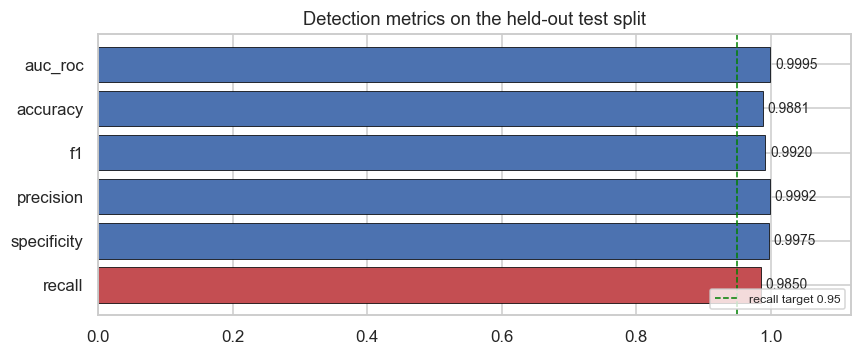

In [3]:
if detection is not None:
    order = ["recall", "specificity", "precision", "f1", "accuracy", "auc_roc"]
    labels = [m for m in order if m in detection]
    values = [detection[m] for m in labels]

    fig, ax = plt.subplots(figsize=(8, 3.4))
    colors = ["#C44E52" if m == "recall" else "#4C72B0" for m in labels]
    bars = ax.barh(labels, values, color=colors, edgecolor="black", linewidth=0.5)
    ax.bar_label(bars, fmt="%.4f", fontsize=9, padding=3)
    ax.set_xlim(0, 1.12)
    ax.axvline(0.95, color="green", ls="--", lw=1, label="recall target 0.95")
    ax.set_title("Detection metrics on the held-out test split")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.show()

### Reading the detection result

Recall and specificity are the two numbers to look at together:

- **Recall (sensitivity)** — of all scans that do contain a tumour, the fraction
  the model flagged. Missing these is the clinically costly error.
- **Specificity** — of all healthy scans, the fraction correctly cleared.

Whichever is lower tells you which way the decision threshold leans. The threshold
is adjustable at inference time (`DETECTION_THRESHOLD` in
`src/inference/pipeline.py`, exposed as a slider in the Streamlit app), so recall
can be bought at the cost of specificity if a use case demands it.

**Important caveat from notebook 01.** A decision tree using only image width,
height and mean brightness — no pixel content — reaches 95.6% on this task, and
81.9% even after preprocessing, against a 75% chance baseline. Part of the score
below reflects acquisition differences between the `notumor` source and the tumour
sources rather than pathology. Do not read it as clinical performance.

## 2. Classification — which tumour type?

Four-way: glioma, meningioma, notumor, pituitary. Plan targets were weighted
F1 >= 0.90 and top-1 accuracy >= 0.92.

In [4]:
classification = results.get("classification")

if classification is None:
    print("No classification results in the report.")
else:
    headline = pd.DataFrame([
        {"metric": "accuracy", "value": classification["accuracy"], "target": 0.92},
        {"metric": "weighted_f1", "value": classification["weighted_f1"], "target": 0.90},
        {"metric": "macro_f1", "value": classification["macro_f1"], "target": ""},
    ])
    headline["meets target"] = [
        "" if t == "" else ("yes" if v >= t else "NO")
        for v, t in zip(headline["value"], headline["target"])
    ]
    display(headline.style.format({"value": "{:.4f}"}).hide(axis="index"))

metric,value,target,meets target
accuracy,0.9569,0.920000,yes
weighted_f1,0.9561,0.900000,yes
macro_f1,0.9561,,


,precision,recall,f1
glioma,0.9913,0.8500,0.9152
meningioma,0.9074,0.9800,0.9423
notumor,0.9569,1.0000,0.9780
pituitary,0.9803,0.9975,0.9888


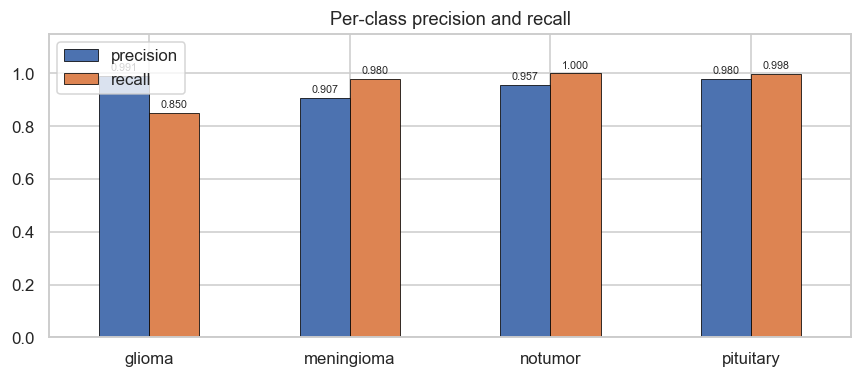

weakest class: glioma (F1 = 0.9152)


In [5]:
if classification is not None:
    per_class = pd.DataFrame({
        "precision": classification["per_class_precision"],
        "recall": classification["per_class_recall"],
    })
    per_class["f1"] = (2 * per_class["precision"] * per_class["recall"]
                       / (per_class["precision"] + per_class["recall"]).replace(0, np.nan))
    display(per_class.style.format("{:.4f}"))

    ax = per_class[["precision", "recall"]].plot(
        kind="bar", figsize=(8, 3.6), rot=0, edgecolor="black", linewidth=0.5)
    ax.set_ylim(0, 1.15)
    ax.set_title("Per-class precision and recall")
    ax.set_xlabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
    plt.tight_layout()
    plt.show()

    worst = per_class["f1"].idxmin()
    print(f"weakest class: {worst} (F1 = {per_class.loc[worst, 'f1']:.4f})")

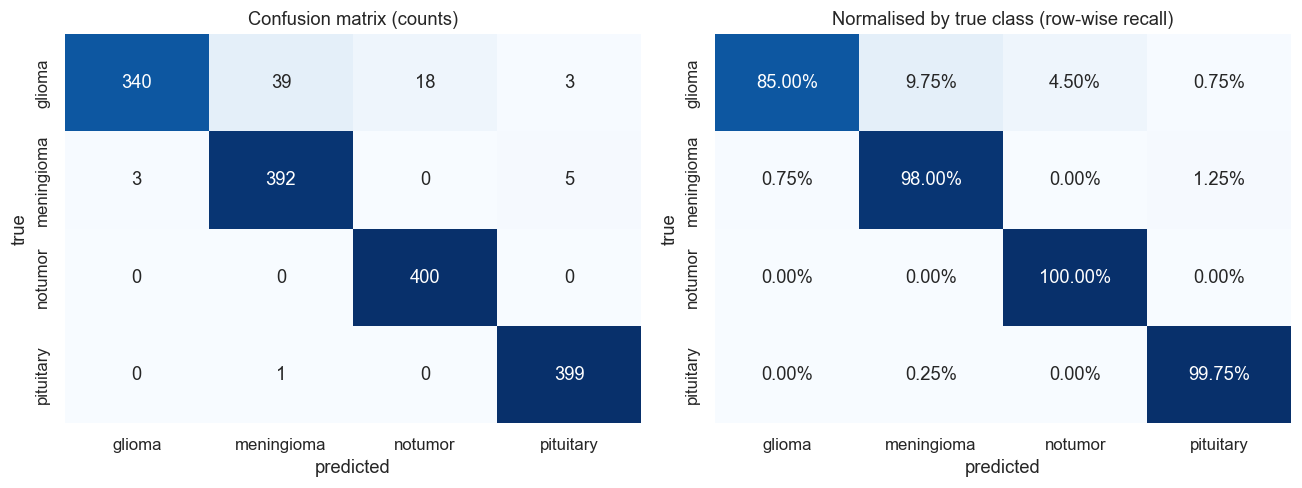

Largest off-diagonal confusions:
  glioma      predicted as meningioma :  39  (9.8% of glioma)
  glioma      predicted as notumor    :  18  (4.5% of glioma)
  meningioma  predicted as pituitary  :   5  (1.2% of meningioma)
  glioma      predicted as pituitary  :   3  (0.8% of glioma)
  meningioma  predicted as glioma     :   3  (0.8% of meningioma)


In [6]:
if classification is not None:
    cm = np.array(classification["confusion_matrix"])
    cm_normalised = cm / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title("Confusion matrix (counts)")
    axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")

    sns.heatmap(cm_normalised, annot=True, fmt=".2%", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_title("Normalised by true class (row-wise recall)")
    axes[1].set_xlabel("predicted"); axes[1].set_ylabel("true")

    plt.tight_layout()
    plt.show()

    print("Largest off-diagonal confusions:")
    pairs = [
        (CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j]), 100 * cm_normalised[i, j])
        for i in range(len(CLASS_NAMES)) for j in range(len(CLASS_NAMES)) if i != j
    ]
    for true_cls, pred_cls, count, pct in sorted(pairs, key=lambda p: -p[2])[:5]:
        if count:
            print(f"  {true_cls:11s} predicted as {pred_cls:11s}: {count:3d}  ({pct:.1f}% of {true_cls})")

### Reading the confusion matrix

The off-diagonal entries are where the clinically interesting errors live:

- **Any tumour predicted as `notumor`** is the most serious error in the matrix —
  a missed diagnosis. Check that column first.
- **glioma <-> meningioma** confusion is the expected difficulty. Both can present
  as enhancing masses, and distinguishing them often depends on location relative
  to the meninges rather than appearance alone.
- **pituitary** is usually the easiest class: these tumours sit in a stereotyped
  anatomical location (the sella turcica), so position alone is highly informative.

## 3. Segmentation — where is the tumour?

**Read this section with the caveat attached.** The reference masks are
intensity-derived *weak labels*, not expert annotations — this dataset ships none.
`generate_pseudo_mask()` takes the brightest compact blob inside the brain, and
notebook 02 showed roughly a third of those land on the actual lesion while the
rest catch eye globes, skull-base structures or ventricles.

So Dice here measures **agreement with that heuristic**, not tumour localisation
accuracy. A high score means the U-Net learned to reproduce the thresholding rule.

Two further details:

- Dice and IoU are averaged only over images that carry a reference lesion.
  `notumor` scans have empty masks, and an empty prediction against an empty
  target scores 1.0 through the smoothing term, which would inflate the mean.
- Those empty-reference scans are scored separately as a true-negative rate: how
  often the model correctly predicted nothing.

In [7]:
segmentation = results.get("segmentation")

if segmentation is None:
    print("No segmentation results in the report.")
else:
    numeric = {k: v for k, v in segmentation.items() if isinstance(v, (int, float))}
    display(pd.DataFrame([numeric]).T.rename(columns={0: "value"}).style.format("{:.4f}"))
    print(f"\nreference masks: {segmentation.get('reference_masks')}")
    print(f"scored on {segmentation.get('scored_images')} lesion-bearing images")
    print(f"{segmentation.get('empty_reference_images')} empty-reference images, "
          f"{100 * segmentation.get('empty_reference_true_negative_rate', 0):.1f}% correctly left blank")

,value
dice,0.5770
iou,0.4933
scored_images,873.0000
empty_reference_images,727.0000
empty_reference_true_negative_rate,0.8308



reference masks: precomputed weak labels
scored on 873 lesion-bearing images
727 empty-reference images, 83.1% correctly left blank


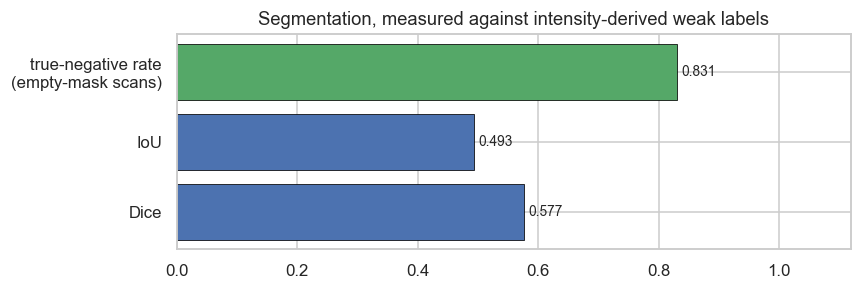

In [8]:
if segmentation is not None:
    fig, ax = plt.subplots(figsize=(8, 2.8))
    labels = ["Dice", "IoU", "true-negative rate\n(empty-mask scans)"]
    values = [segmentation["dice"], segmentation["iou"],
              segmentation["empty_reference_true_negative_rate"]]
    bars = ax.barh(labels, values, color=["#4C72B0", "#4C72B0", "#55A868"],
                   edgecolor="black", linewidth=0.5)
    ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=3)
    ax.set_xlim(0, 1.12)
    ax.set_title("Segmentation, measured against intensity-derived weak labels")
    plt.tight_layout()
    plt.show()

## 4. Summary against the plan's targets

In [9]:
targets = [
    ("Detection", "Recall (sensitivity)", results.get("detection", {}).get("recall"), 0.95),
    ("Detection", "AUC-ROC", results.get("detection", {}).get("auc_roc"), 0.97),
    ("Classification", "Weighted F1", results.get("classification", {}).get("weighted_f1"), 0.90),
    ("Classification", "Top-1 accuracy", results.get("classification", {}).get("accuracy"), 0.92),
    ("Segmentation", "Dice (vs weak labels)", results.get("segmentation", {}).get("dice"), 0.75),
    ("Segmentation", "IoU (vs weak labels)", results.get("segmentation", {}).get("iou"), 0.65),
]

summary = pd.DataFrame(
    [{"task": t, "metric": m, "achieved": v, "target": g,
      "status": "not run" if v is None else ("met" if v >= g else "below")}
     for t, m, v, g in targets]
)
display(summary.style.format({"achieved": "{:.4f}", "target": "{:.2f}"}, na_rep="-")
        .hide(axis="index"))

task,metric,achieved,target,status
Detection,Recall (sensitivity),0.9850,0.95,met
Detection,AUC-ROC,0.9995,0.97,met
Classification,Weighted F1,0.9561,0.90,met
Classification,Top-1 accuracy,0.9569,0.92,met
Segmentation,Dice (vs weak labels),0.5770,0.75,below
Segmentation,IoU (vs weak labels),0.4933,0.65,below


## What these numbers do and do not support

**Supported:**

- The pipeline trains, converges and generalises from the training split to a
  held-out test split of 1600 images it never saw.
- Detection and classification results are directly comparable to the plan's
  targets, and were produced by a single reproducible command.

**Not supported:**

- *Clinical performance.* Notebook 01 established that this dataset carries an
  acquisition confound: `notumor` images come from a different source with
  different resolutions and roughly double the mean brightness, and a decision
  tree using only that metadata reaches 95.6% on detection (81.9% after
  preprocessing) against a 75% baseline. Some of the detection score is source
  recognition, not pathology.
- *Tumour localisation.* The segmentation reference masks are weak labels. Dice
  measures agreement with an intensity heuristic that is right about a third of
  the time.

**What would strengthen the work:**

1. Train segmentation against expert annotations — the figshare collection
   (https://doi.org/10.6084/m9.figshare.1512427.v5, CC BY 4.0) covers these same
   three tumour types with manually traced borders.
2. Evaluate on an external dataset. Cross-source accuracy is the honest measure of
   generalisation and would quantify how much of the score is the confound.
3. Add Grad-CAM overlays to confirm the classifier attends to the lesion rather
   than to image borders or acquisition artefacts.